In [1]:
# Install required packages
%pip install -q ultralytics opencv-python

import os
import random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

# PyTorch / Ultralytics imports
import torch
from ultralytics import YOLO

# Fix all random seeds for reproducibility
SEED = 993
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print('Environment set up. Random seed fixed to', SEED)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 80.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Environment set up. Random seed fixed to 993


In [2]:
# === Data extraction ===

from pathlib import Path
import zipfile
import shutil
import os

NOTEBOOK_DIR = Path.cwd()

# Куда распаковываем данные
extract_root = NOTEBOOK_DIR / "competition_data"

# Возможные имена архива
archive_name_candidates = [
    "2026-cv-competition.zip",
    "competition.zip",
    "data.zip",
]

# Ищем zip-кандидаты в корне и вложенно
zip_candidates = []

for name in archive_name_candidates:
    zip_candidates.append(NOTEBOOK_DIR / name)

zip_candidates += sorted(NOTEBOOK_DIR.rglob("*.zip"))

# Убираем дубли
seen = set()
zip_candidates_unique = []

for p in zip_candidates:
    p = p.resolve()
    if p not in seen:
        seen.add(p)
        zip_candidates_unique.append(p)

print("Found zip candidates:")
for p in zip_candidates_unique:
    if p.exists():
        size_mb = p.stat().st_size / 1024 / 1024
        is_valid = zipfile.is_zipfile(p)
        print(f"  {p} | size={size_mb:.2f} MB | is_zip={is_valid}")

# Берём первый настоящий zip
zip_path = None

for candidate in zip_candidates_unique:
    if candidate.exists() and candidate.is_file() and zipfile.is_zipfile(candidate):
        zip_path = candidate
        break

# Если валидного zip нет, проверяем, может датасет уже распакован
if zip_path is None:
    possible_unpacked_roots = [
        NOTEBOOK_DIR / "2026-cv-competition",
        NOTEBOOK_DIR / "competition_data",
        NOTEBOOK_DIR,
    ]

    def looks_like_dataset(root: Path):
        if not root.exists():
            return False

        has_sample = len(list(root.rglob("sample_submission.csv"))) > 0
        has_train_images = any(
            p.is_dir() and p.name == "images" and "train" in str(p).lower()
            for p in root.rglob("*")
        )
        has_train_labels = any(
            p.is_dir() and p.name == "labels" and "train" in str(p).lower()
            for p in root.rglob("*")
        )
        has_test = any(
            p.is_dir() and "test" in str(p).lower()
            for p in root.rglob("*")
        )

        return has_sample and has_train_images and has_train_labels and has_test

    for root_candidate in possible_unpacked_roots:
        if looks_like_dataset(root_candidate):
            extract_root = root_candidate
            print("Valid zip was not found, but unpacked dataset was found:", extract_root)
            break
    else:
        # Диагностика первого найденного zip-файла
        bad_files = [p for p in zip_candidates_unique if p.exists() and p.is_file()]
        if bad_files:
            bad = bad_files[0]
            print("\nFirst bytes of invalid file:")
            with open(bad, "rb") as f:
                print(f.read(300))

        raise FileNotFoundError(
            "No valid zip archive was found and no unpacked dataset was detected. "
            "Check that the real 2026-cv-competition.zip is placed in the notebook root."
        )

else:
    print("\nUsing valid archive:", zip_path)

    # Чистим старую распаковку
    if extract_root.exists():
        shutil.rmtree(extract_root)

    extract_root.mkdir(parents=True, exist_ok=True)

    def is_macos_artifact(filename: str) -> bool:
        parts = Path(filename).parts

        if "__MACOSX" in parts:
            return True

        if any(part.startswith("._") for part in parts):
            return True

        if any(part == ".DS_Store" for part in parts):
            return True

        return False

    with zipfile.ZipFile(zip_path, "r") as z:
        members = z.infolist()

        valid_members = [
            m for m in members
            if not is_macos_artifact(m.filename)
        ]

        print("Total archive members:", len(members))
        print("Valid members extracted:", len(valid_members))
        print("Skipped macOS artifacts:", len(members) - len(valid_members))

        for member in valid_members:
            z.extract(member, extract_root)

    print("Dataset extracted to:", extract_root)

print("\nFirst extracted/found files:")
for p in sorted(extract_root.rglob("*"))[:80]:
    print(p)

Found zip candidates:
  /content/2026-cv-competition.zip | size=136.90 MB | is_zip=True

Using valid archive: /content/2026-cv-competition.zip
Total archive members: 7656
Valid members extracted: 3825
Skipped macOS artifacts: 3831
Dataset extracted to: /content/competition_data

First extracted/found files:
/content/competition_data/2026-cv-competition
/content/competition_data/2026-cv-competition/sample_submission.csv
/content/competition_data/2026-cv-competition/test
/content/competition_data/2026-cv-competition/test/images
/content/competition_data/2026-cv-competition/test/images/IMG20240228122809_jpg.rf.bb184f37aa98d96f1db1ac5492b4c81c.jpg
/content/competition_data/2026-cv-competition/test/images/IMG20240228122949_jpg.rf.f763b523e7bb4e72507961519cbbef88.jpg
/content/competition_data/2026-cv-competition/test/images/IMG20240228122955_jpg.rf.18d6c6ad9c8c69153da34c4074004853.jpg
/content/competition_data/2026-cv-competition/test/images/IMG20240228123115_jpg.rf.3b9ae83d0bc7242bafe52e60c

train_images_dir: /content/competition_data/2026-cv-competition/train/images
train_labels_dir: /content/competition_data/2026-cv-competition/train/labels
test_images_dir: /content/competition_data/2026-cv-competition/test/images
sample_submission_path: /content/competition_data/2026-cv-competition/sample_submission.csv
Filtered label files: 1697

Sample submission shape: (424, 2)


,image_id,PredictionString
0,IMG20240228122809_jpg.rf.bb184f37aa98d96f1db1a...,NaN
1,IMG20240228122949_jpg.rf.f763b523e7bb4e7250796...,NaN
2,IMG20240228122955_jpg.rf.18d6c6ad9c8c69153da34...,NaN
3,IMG20240228123115_jpg.rf.3b9ae83d0bc7242bafe52...,NaN
4,IMG20240228123131_jpg.rf.84cf43cf1c7a8d09dc507...,NaN



Number of train images: 1697
Number of label files: 1697
Number of test images: 424


Parsing label files:   0%|          | 0/1697 [00:00<?, ?it/s]


Number of classes found: 52
Total objects: 10498
Mean objects per image: 6.1862109605185625
Median objects per image: 6.0


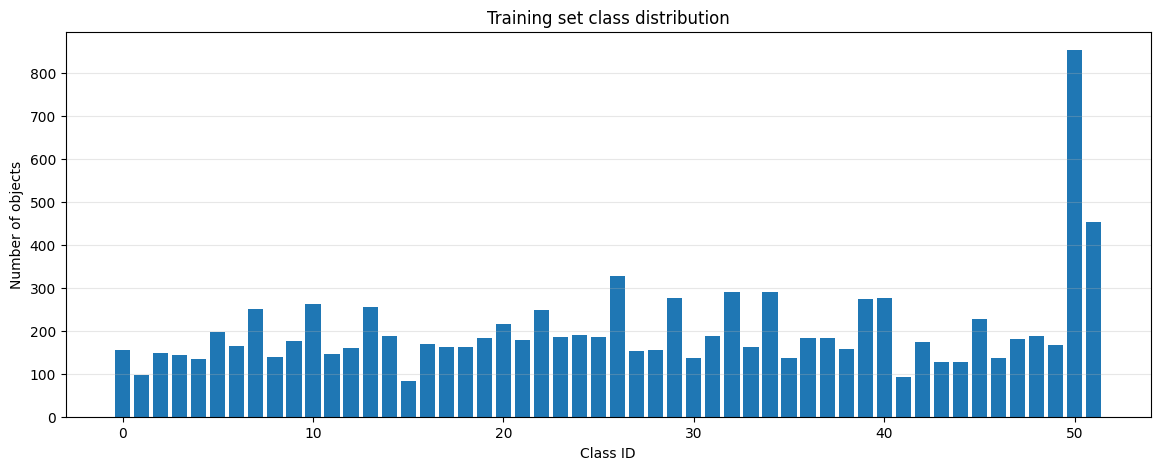

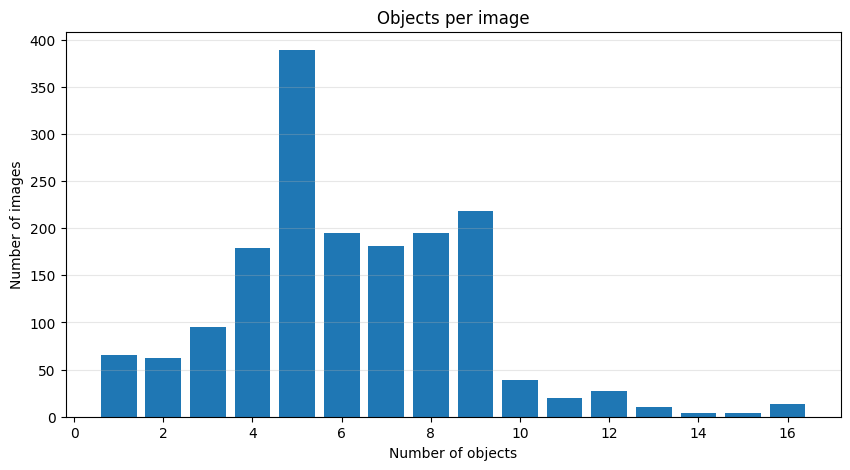

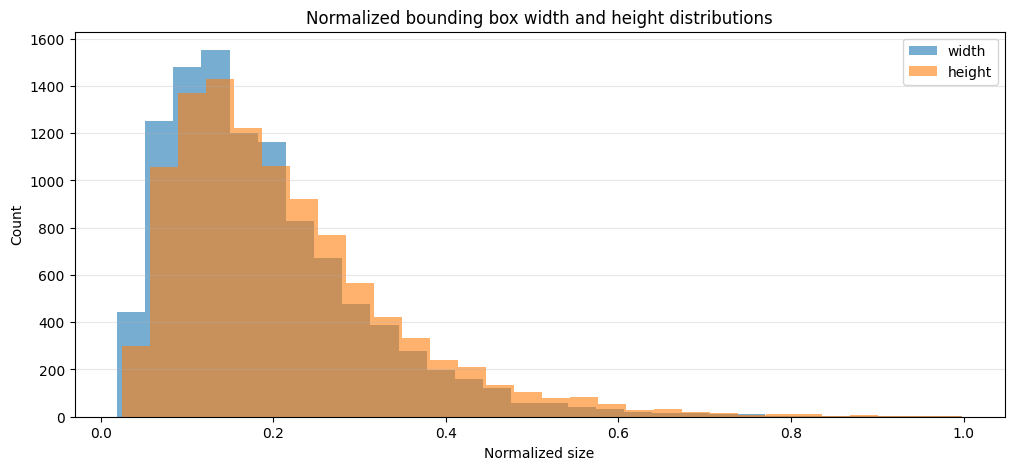

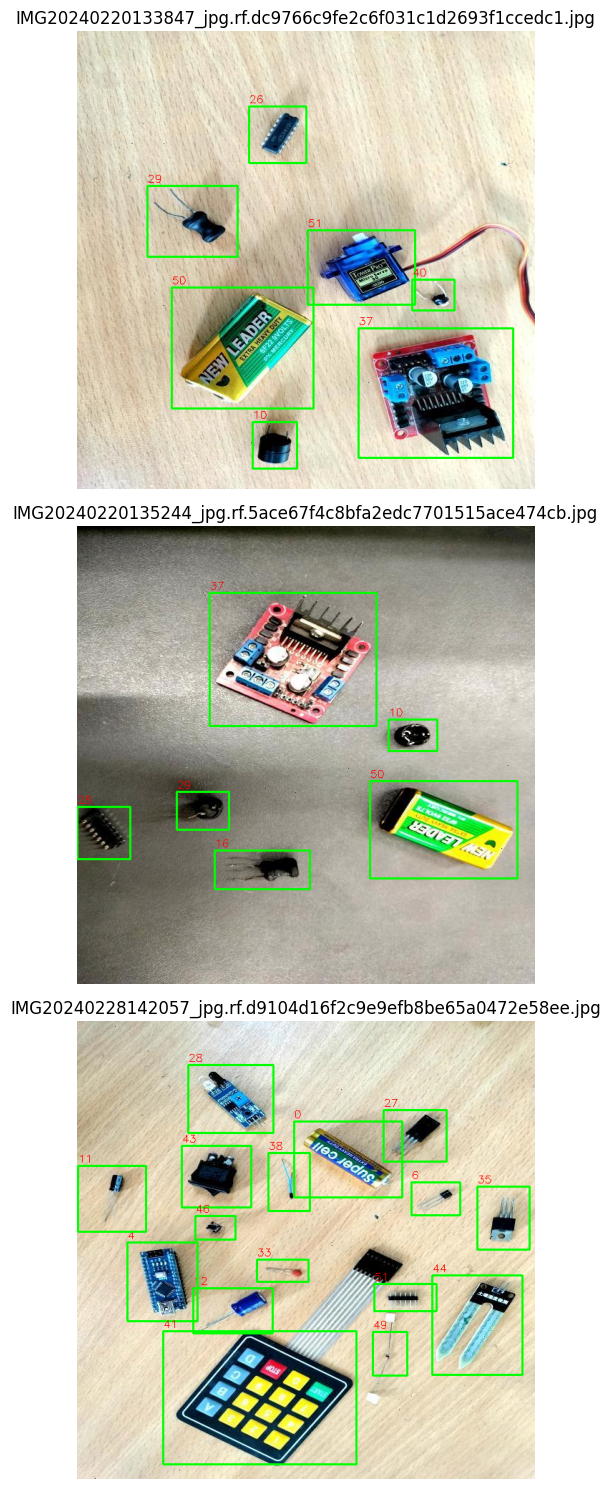

In [3]:
# === Data exploration and automatic path discovery ===

from pathlib import Path
import pandas as pd
import numpy as np
import random
import cv2
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}

def has_images(path: Path):
    return any(p.is_file() and p.suffix in IMAGE_EXTS for p in path.iterdir())

def count_images(path: Path):
    return sum(1 for p in path.iterdir() if p.is_file() and p.suffix in IMAGE_EXTS)

# 1. Automatically find train/images
train_images_candidates = [
    p for p in extract_root.rglob("*")
    if p.is_dir()
    and p.name == "images"
    and "train" in str(p).lower()
    and has_images(p)
]

# 2. Automatically find train/labels
train_labels_candidates = [
    p for p in extract_root.rglob("*")
    if p.is_dir()
    and p.name == "labels"
    and "train" in str(p).lower()
]

# 3. Automatically find test images:
# Either test/images or just test with images directly inside.
test_images_candidates = [
    p for p in extract_root.rglob("*")
    if p.is_dir()
    and "test" in str(p).lower()
    and has_images(p)
]

# 4. Automatically find sample_submission.csv
sample_candidates = list(extract_root.rglob("sample_submission.csv"))

assert len(train_images_candidates) > 0, "train/images folder was not found"
assert len(train_labels_candidates) > 0, "train/labels folder was not found"
assert len(test_images_candidates) > 0, "test image folder was not found"
assert len(sample_candidates) > 0, "sample_submission.csv was not found"

train_images_dir = train_images_candidates[0]
train_labels_dir = train_labels_candidates[0]
test_images_dir = sorted(test_images_candidates, key=count_images, reverse=True)[0]
sample_submission_path = sample_candidates[0]

print("train_images_dir:", train_images_dir)
print("train_labels_dir:", train_labels_dir)
print("test_images_dir:", test_images_dir)
print("sample_submission_path:", sample_submission_path)

# 5. Collect paths
train_images = []
for ext in IMAGE_EXTS:
    train_images.extend(train_images_dir.glob(f"*{ext}"))

test_images = []
for ext in IMAGE_EXTS:
    test_images.extend(test_images_dir.glob(f"*{ext}"))

train_images = sorted(train_images)
test_images = sorted(test_images)
# Берём только те label-файлы, которые соответствуют train-картинкам
train_image_stems = {p.stem for p in train_images}

label_files = sorted([
    p for p in train_labels_dir.glob("*.txt")
    if p.stem in train_image_stems
])

print("Filtered label files:", len(label_files))
sample_df = pd.read_csv(sample_submission_path)

print("\nSample submission shape:", sample_df.shape)
display(sample_df.head())

print("\nNumber of train images:", len(train_images))
print("Number of label files:", len(label_files))
print("Number of test images:", len(test_images))

assert len(train_images) > 0, "No train images found"
assert len(test_images) > 0, "No test images found"
assert len(label_files) > 0, "No label files found"

# 6. Parse labels to get class distribution and bounding box sizes
class_counts = {}
box_widths = []
box_heights = []
objects_per_image = []

for lbl in tqdm(label_files, desc="Parsing label files"):
    image_object_count = 0

    with open(lbl, "r") as f:
        for line in f:
            parts = line.strip().split()

            if not parts:
                continue

            cls_id = int(float(parts[0]))

            # YOLO format in labels:
            # class_id x_center y_center width height
            w = float(parts[3])
            h = float(parts[4])

            box_widths.append(w)
            box_heights.append(h)

            class_counts[cls_id] = class_counts.get(cls_id, 0) + 1
            image_object_count += 1

    objects_per_image.append(image_object_count)

print("\nNumber of classes found:", len(class_counts))
print("Total objects:", sum(class_counts.values()))
print("Mean objects per image:", np.mean(objects_per_image))
print("Median objects per image:", np.median(objects_per_image))

# 7. Plot class distribution
plt.figure(figsize=(14, 5))
plt.bar(sorted(class_counts.keys()), [class_counts[k] for k in sorted(class_counts.keys())])
plt.title("Training set class distribution")
plt.xlabel("Class ID")
plt.ylabel("Number of objects")
plt.grid(axis="y", alpha=0.3)
plt.show()

# 8. Plot objects per image
plt.figure(figsize=(10, 5))
plt.hist(objects_per_image, bins=range(1, max(objects_per_image) + 2), align="left", rwidth=0.8)
plt.title("Objects per image")
plt.xlabel("Number of objects")
plt.ylabel("Number of images")
plt.grid(axis="y", alpha=0.3)
plt.show()

# 9. Show bounding box size distribution
plt.figure(figsize=(12, 5))
plt.hist(box_widths, bins=30, alpha=0.6, label="width")
plt.hist(box_heights, bins=30, alpha=0.6, label="height")
plt.title("Normalized bounding box width and height distributions")
plt.xlabel("Normalized size")
plt.ylabel("Count")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

# 10. Show sample images with annotations
def show_samples(n=3):
    n = min(n, len(train_images))
    sample_imgs = random.sample(train_images, n)

    plt.figure(figsize=(15, 5 * n))

    for i, img_path in enumerate(sample_imgs):
        img_bgr = cv2.imread(str(img_path))
        assert img_bgr is not None, f"Cannot read image: {img_path}"

        img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        label_path = train_labels_dir / f"{img_path.stem}.txt"

        # Draw boxes
        if label_path.exists():
            with open(label_path, "r") as f:
                for line in f:
                    parts = line.strip().split()

                    if len(parts) < 5:
                        continue

                    cls_id, x_c, y_c, bw, bh = map(float, parts[:5])

                    x_c_px = x_c * w
                    y_c_px = y_c * h
                    bw_px = bw * w
                    bh_px = bh * h

                    x1 = int(x_c_px - bw_px / 2)
                    y1 = int(y_c_px - bh_px / 2)
                    x2 = int(x_c_px + bw_px / 2)
                    y2 = int(y_c_px + bh_px / 2)

                    x1 = max(0, min(w - 1, x1))
                    y1 = max(0, min(h - 1, y1))
                    x2 = max(0, min(w - 1, x2))
                    y2 = max(0, min(h - 1, y2))

                    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    cv2.putText(
                        img,
                        str(int(cls_id)),
                        (x1, max(0, y1 - 5)),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5,
                        (255, 0, 0),
                        1
                    )

        plt.subplot(n, 1, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_path.name)

    plt.tight_layout()
    plt.show()

show_samples(3)

In [4]:
# === Prepare YOLO dataset and create data.yaml ===

from pathlib import Path
import shutil
import random
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

SEED = 993

random.seed(SEED)
np.random.seed(SEED)

# Папка, куда соберём датасет в формате Ultralytics YOLO
YOLO_DATASET_ROOT = extract_root / "yolo_dataset"

# Если уже создавался — удаляем, чтобы не было старых файлов
if YOLO_DATASET_ROOT.exists():
    shutil.rmtree(YOLO_DATASET_ROOT)

for split in ["train", "val"]:
    (YOLO_DATASET_ROOT / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DATASET_ROOT / "labels" / split).mkdir(parents=True, exist_ok=True)

# Берём только найденные реальные train-картинки
all_train_images = sorted(train_images)

assert len(all_train_images) > 0, "train_images пустой. Проверь ячейку поиска путей."

# Train/val split
train_imgs, val_imgs = train_test_split(
    all_train_images,
    test_size=0.2,
    random_state=SEED,
    shuffle=True
)

print("Train images:", len(train_imgs))
print("Val images:", len(val_imgs))


def copy_yolo_split(image_paths, split_name):
    image_out_dir = YOLO_DATASET_ROOT / "images" / split_name
    label_out_dir = YOLO_DATASET_ROOT / "labels" / split_name

    missing_labels = []

    for img_path in tqdm(image_paths, desc=f"Copying {split_name}"):
        # copy image
        dst_img = image_out_dir / img_path.name
        shutil.copy(img_path, dst_img)

        # copy corresponding label
        src_label = train_labels_dir / f"{img_path.stem}.txt"
        dst_label = label_out_dir / f"{img_path.stem}.txt"

        if src_label.exists():
            shutil.copy(src_label, dst_label)
        else:
            missing_labels.append(src_label)

    if missing_labels:
        print(f"Missing labels in {split_name}:", len(missing_labels))
        print("First missing labels:")
        for p in missing_labels[:10]:
            print(p)

    assert len(missing_labels) == 0, f"Есть картинки без label-файлов в {split_name}"


copy_yolo_split(train_imgs, "train")
copy_yolo_split(val_imgs, "val")

# Количество классов
NC = 52
class_names = [f"class_{i}" for i in range(NC)]

# Создаём data.yaml для Ultralytics
yaml_path = YOLO_DATASET_ROOT / "data.yaml"

yaml_text = (
    f"path: {YOLO_DATASET_ROOT}\n"
    "train: images/train\n"
    "val: images/val\n\n"
    f"nc: {NC}\n"
    f"names: {class_names}\n"
)

with open(yaml_path, "w", encoding="utf-8") as f:
    f.write(yaml_text)

print("\nYOLO dataset root:", YOLO_DATASET_ROOT)
print("yaml_path:", yaml_path)
print("\nYAML content:")
print(yaml_text)

# Проверка, что всё создано корректно
assert yaml_path.exists(), "data.yaml не создан"
assert (YOLO_DATASET_ROOT / "images/train").exists()
assert (YOLO_DATASET_ROOT / "labels/train").exists()
assert (YOLO_DATASET_ROOT / "images/val").exists()
assert (YOLO_DATASET_ROOT / "labels/val").exists()

print("YOLO dataset preparation completed.")

Train images: 1357
Val images: 340


Copying train:   0%|          | 0/1357 [00:00<?, ?it/s]

Copying val:   0%|          | 0/340 [00:00<?, ?it/s]


YOLO dataset root: /content/competition_data/yolo_dataset
yaml_path: /content/competition_data/yolo_dataset/data.yaml

YAML content:
path: /content/competition_data/yolo_dataset
train: images/train
val: images/val

nc: 52
names: ['class_0', 'class_1', 'class_2', 'class_3', 'class_4', 'class_5', 'class_6', 'class_7', 'class_8', 'class_9', 'class_10', 'class_11', 'class_12', 'class_13', 'class_14', 'class_15', 'class_16', 'class_17', 'class_18', 'class_19', 'class_20', 'class_21', 'class_22', 'class_23', 'class_24', 'class_25', 'class_26', 'class_27', 'class_28', 'class_29', 'class_30', 'class_31', 'class_32', 'class_33', 'class_34', 'class_35', 'class_36', 'class_37', 'class_38', 'class_39', 'class_40', 'class_41', 'class_42', 'class_43', 'class_44', 'class_45', 'class_46', 'class_47', 'class_48', 'class_49', 'class_50', 'class_51']

YOLO dataset preparation completed.


In [5]:
# Training YOLO model with built-in augmentation parameters

# Create a YOLO model (pretrained on COCO)
model = YOLO('yolov8m.pt')

results = model.train(
    data=str(yaml_path),
    epochs=80,
    imgsz=640,
    batch=16,
    seed=SEED,
    device=0 if torch.cuda.is_available() else 'cpu',
    patience=20,
    optimizer='AdamW',
    lr0=0.001,
    weight_decay=0.0005,
    # Colour and brightness augmentations
    hsv_h=0.04,
    hsv_s=0.65,
    hsv_v=0.45,
    # Geometric augmentations
    degrees=10.0,
    translate=0.10,
    scale=0.40,
    shear=2.0,
    perspective=0.0005,
    # Flips
    fliplr=0.5,
    flipud=0.15,
    # Mosaic and mixup to simulate clutter and occlusions
    mosaic=0.8,
    mixup=0.05,
    copy_paste=0.0,
    close_mosaic=10,
)



Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/competition_data/yolo_dataset/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.15, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.04, hsv_s=0.65, hsv_v=0.45, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=0.8, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mas

In [8]:
# === Find best weights after main training ===

from pathlib import Path

search_roots = [
    Path.cwd() / "runs",
    Path("/content/runs"),
]

possible_best_weights = []
possible_last_weights = []

for root in search_roots:
    if root.exists():
        possible_best_weights.extend(list(root.rglob("weights/best.pt")))
        possible_last_weights.extend(list(root.rglob("weights/last.pt")))

possible_best_weights = sorted(
    list(set(possible_best_weights)),
    key=lambda p: p.stat().st_mtime,
    reverse=True
)

possible_last_weights = sorted(
    list(set(possible_last_weights)),
    key=lambda p: p.stat().st_mtime,
    reverse=True
)

print("Found best.pt files:")
for p in possible_best_weights:
    print(p)

if len(possible_best_weights) > 0:
    best_weights_path = possible_best_weights[0]
elif len(possible_last_weights) > 0:
    best_weights_path = possible_last_weights[0]
else:
    raise FileNotFoundError("Не найден best.pt или last.pt. Проверь, что training-ячейка выполнилась.")

print("Training completed.")
print("Best weights path:", best_weights_path)
print("Exists:", best_weights_path.exists())

Found best.pt files:
/content/runs/detect/train/weights/best.pt
Training completed.
Best weights path: /content/runs/detect/train/weights/best.pt
Exists: True


In [9]:
# === Domain fine-tuning dataset: clean train -> degraded test-like train ===

from pathlib import Path
import shutil
import cv2
import numpy as np
import random
from tqdm.notebook import tqdm

SEED = 993

random.seed(SEED)
np.random.seed(SEED)

# Берём уже подготовленный YOLO split из предыдущей ячейки.
# Там должен быть создан YOLO_DATASET_ROOT и yaml_path.
try:
    YOLO_DATASET_ROOT
except NameError:
    YOLO_DATASET_ROOT = extract_root / "yolo_dataset"

YOLO_DATASET_ROOT = Path(YOLO_DATASET_ROOT)

CLEAN_YOLO_ROOT = YOLO_DATASET_ROOT

CLEAN_TRAIN_IMAGES = CLEAN_YOLO_ROOT / "images" / "train"
CLEAN_TRAIN_LABELS = CLEAN_YOLO_ROOT / "labels" / "train"

CLEAN_VAL_IMAGES = CLEAN_YOLO_ROOT / "images" / "val"
CLEAN_VAL_LABELS = CLEAN_YOLO_ROOT / "labels" / "val"

# Новый degraded dataset создаём рядом с обычным yolo_dataset
DOMAIN_ROOT = extract_root / "yolo_degraded_dataset"

assert CLEAN_TRAIN_IMAGES.exists(), f"Не найдена папка: {CLEAN_TRAIN_IMAGES}"
assert CLEAN_TRAIN_LABELS.exists(), f"Не найдена папка: {CLEAN_TRAIN_LABELS}"
assert CLEAN_VAL_IMAGES.exists(), f"Не найдена папка: {CLEAN_VAL_IMAGES}"
assert CLEAN_VAL_LABELS.exists(), f"Не найдена папка: {CLEAN_VAL_LABELS}"

if DOMAIN_ROOT.exists():
    shutil.rmtree(DOMAIN_ROOT)

for split in ["train", "val"]:
    (DOMAIN_ROOT / "images" / split).mkdir(parents=True, exist_ok=True)
    (DOMAIN_ROOT / "labels" / split).mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}


def list_images(folder: Path):
    return sorted([
        p for p in folder.iterdir()
        if p.is_file()
        and p.suffix in IMAGE_EXTS
        and not p.name.startswith("._")
        and "__MACOSX" not in p.parts
    ])


train_imgs = list_images(CLEAN_TRAIN_IMAGES)
val_imgs = list_images(CLEAN_VAL_IMAGES)

print("CLEAN_YOLO_ROOT:", CLEAN_YOLO_ROOT)
print("DOMAIN_ROOT:", DOMAIN_ROOT)
print("Clean train images:", len(train_imgs))
print("Clean val images:", len(val_imgs))

assert len(train_imgs) > 0, "В CLEAN_TRAIN_IMAGES не найдены изображения"
assert len(val_imgs) > 0, "В CLEAN_VAL_IMAGES не найдены изображения"


def apply_color_cast(img, rng):
    """
    Имитирует серую/розовую/зелёную/голубую заливку как на test.
    img: BGR uint8.
    """
    out = img.astype(np.float32)

    mode = rng.choice(["gray", "pink", "green", "blue", "yellow", "normal"])

    if mode == "gray":
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        gray3 = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR).astype(np.float32)
        alpha = rng.uniform(0.65, 0.95)
        out = alpha * gray3 + (1 - alpha) * out

    elif mode == "pink":
        cast = np.array([rng.uniform(0.85, 1.05), rng.uniform(0.70, 0.95), rng.uniform(1.10, 1.45)])
        out *= cast

    elif mode == "green":
        cast = np.array([rng.uniform(0.85, 1.15), rng.uniform(1.10, 1.45), rng.uniform(0.75, 1.00)])
        out *= cast

    elif mode == "blue":
        cast = np.array([rng.uniform(1.15, 1.55), rng.uniform(0.90, 1.15), rng.uniform(0.75, 1.00)])
        out *= cast

    elif mode == "yellow":
        cast = np.array([rng.uniform(0.65, 0.90), rng.uniform(1.05, 1.30), rng.uniform(1.05, 1.35)])
        out *= cast

    return np.clip(out, 0, 255).astype(np.uint8)


def add_salt_pepper_noise(img, rng):
    """
    Чёрные/белые точки как на test.
    """
    out = img.copy()
    h, w = out.shape[:2]

    # Доля пикселей под шум. На test шум довольно сильный.
    amount = rng.uniform(0.002, 0.018)
    n = int(h * w * amount)

    ys = rng.integers(0, h, size=n)
    xs = rng.integers(0, w, size=n)

    # Часть точек чёрные, часть белые
    mask = rng.random(n) < 0.65
    out[ys[mask], xs[mask]] = 0
    out[ys[~mask], xs[~mask]] = 255

    return out


def add_gaussian_noise(img, rng):
    """
    Цветной/серый шум.
    """
    sigma = rng.uniform(8, 35)
    noise = rng.normal(0, sigma, img.shape).astype(np.float32)
    out = img.astype(np.float32) + noise
    return np.clip(out, 0, 255).astype(np.uint8)


def add_lines_and_bands(img, rng):
    """
    Вертикальные/горизонтальные полосы и тёмные линии.
    """
    out = img.copy()
    h, w = out.shape[:2]

    # Тонкие линии
    n_lines = rng.integers(1, 7)
    for _ in range(n_lines):
        vertical = rng.random() < 0.55
        dark = rng.random() < 0.75

        if vertical:
            x = int(rng.integers(0, w))
            thickness = int(rng.integers(1, 5))
            x1 = max(0, x - thickness // 2)
            x2 = min(w, x + thickness // 2 + 1)
            value = rng.integers(0, 55) if dark else rng.integers(190, 256)
            out[:, x1:x2, :] = value
        else:
            y = int(rng.integers(0, h))
            thickness = int(rng.integers(1, 5))
            y1 = max(0, y - thickness // 2)
            y2 = min(h, y + thickness // 2 + 1)
            value = rng.integers(0, 55) if dark else rng.integers(190, 256)
            out[y1:y2, :, :] = value

    # Широкие полупрозрачные полосы
    if rng.random() < 0.45:
        n_bands = rng.integers(1, 4)
        for _ in range(n_bands):
            vertical = rng.random() < 0.5
            alpha = rng.uniform(0.15, 0.45)
            delta = rng.integers(-80, 81)

            if vertical:
                x = int(rng.integers(0, w))
                thickness = int(rng.integers(8, 45))
                x1 = max(0, x - thickness // 2)
                x2 = min(w, x + thickness // 2)
                patch = out[:, x1:x2, :].astype(np.float32)
                patch = patch * (1 - alpha) + np.clip(patch + delta, 0, 255) * alpha
                out[:, x1:x2, :] = np.clip(patch, 0, 255).astype(np.uint8)
            else:
                y = int(rng.integers(0, h))
                thickness = int(rng.integers(8, 45))
                y1 = max(0, y - thickness // 2)
                y2 = min(h, y + thickness // 2)
                patch = out[y1:y2, :, :].astype(np.float32)
                patch = patch * (1 - alpha) + np.clip(patch + delta, 0, 255) * alpha
                out[y1:y2, :, :] = np.clip(patch, 0, 255).astype(np.uint8)

    return out


def pixelate_image(img, rng):
    """
    Сильная пикселизация: downscale -> upscale.
    """
    h, w = img.shape[:2]

    # Чем меньше scale, тем сильнее пикселизация
    scale = rng.uniform(0.18, 0.55)

    small_w = max(16, int(w * scale))
    small_h = max(16, int(h * scale))

    interpolation_down = cv2.INTER_AREA
    interpolation_up = cv2.INTER_NEAREST if rng.random() < 0.65 else cv2.INTER_LINEAR

    small = cv2.resize(img, (small_w, small_h), interpolation=interpolation_down)
    out = cv2.resize(small, (w, h), interpolation=interpolation_up)

    return out


def jpeg_compress(img, rng):
    """
    JPEG artifacts.
    """
    quality = int(rng.integers(12, 65))
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
    ok, enc = cv2.imencode(".jpg", img, encode_param)

    if ok:
        return cv2.imdecode(enc, cv2.IMREAD_COLOR)

    return img


def motion_blur(img, rng):
    """
    Motion blur по горизонтали/вертикали/диагонали.
    """
    k = int(rng.choice([3, 5, 7, 9, 11]))
    kernel = np.zeros((k, k), dtype=np.float32)

    mode = rng.choice(["horizontal", "vertical", "diag1", "diag2"])

    if mode == "horizontal":
        kernel[k // 2, :] = 1.0
    elif mode == "vertical":
        kernel[:, k // 2] = 1.0
    elif mode == "diag1":
        np.fill_diagonal(kernel, 1.0)
    else:
        np.fill_diagonal(np.fliplr(kernel), 1.0)

    kernel /= kernel.sum()
    return cv2.filter2D(img, -1, kernel)


def chromatic_shift(img, rng):
    """
    Небольшое смещение цветовых каналов, как при плохом сжатии/съёмке.
    """
    b, g, r = cv2.split(img)

    dx1 = int(rng.integers(-3, 4))
    dy1 = int(rng.integers(-3, 4))
    dx2 = int(rng.integers(-3, 4))
    dy2 = int(rng.integers(-3, 4))

    M1 = np.float32([[1, 0, dx1], [0, 1, dy1]])
    M2 = np.float32([[1, 0, dx2], [0, 1, dy2]])

    b = cv2.warpAffine(b, M1, (img.shape[1], img.shape[0]), borderMode=cv2.BORDER_REFLECT)
    r = cv2.warpAffine(r, M2, (img.shape[1], img.shape[0]), borderMode=cv2.BORDER_REFLECT)

    return cv2.merge([b, g, r])


def posterize(img, rng):
    """
    Уменьшение числа уровней цвета: блочность/плохая глубина цвета.
    """
    levels = int(rng.choice([8, 12, 16, 24, 32]))
    out = img.astype(np.float32)
    out = np.floor(out / 256 * levels) / levels * 256
    return np.clip(out, 0, 255).astype(np.uint8)


def degrade_image(img, seed_value):
    """
    Делает train-картинку похожей на test.
    Важно: геометрия объектов не меняется, поэтому bbox labels остаются корректными.
    """
    rng = np.random.default_rng(seed_value)
    out = img.copy()

    # 1. Цветовая заливка / серость
    if rng.random() < 0.85:
        out = apply_color_cast(out, rng)

    # 2. Яркость/контраст
    if rng.random() < 0.90:
        alpha = rng.uniform(0.55, 1.55)   # contrast
        beta = rng.uniform(-45, 45)       # brightness
        out = np.clip(out.astype(np.float32) * alpha + beta, 0, 255).astype(np.uint8)

    # 3. Пикселизация
    if rng.random() < 0.85:
        out = pixelate_image(out, rng)

    # 4. Blur
    if rng.random() < 0.55:
        k = int(rng.choice([3, 5, 7, 9]))
        out = cv2.GaussianBlur(out, (k, k), 0)

    # 5. Motion blur
    if rng.random() < 0.35:
        out = motion_blur(out, rng)

    # 6. JPEG artifacts
    if rng.random() < 0.80:
        out = jpeg_compress(out, rng)

    # 7. Posterization
    if rng.random() < 0.35:
        out = posterize(out, rng)

    # 8. Цветовое смещение каналов
    if rng.random() < 0.45:
        out = chromatic_shift(out, rng)

    # 9. Gaussian noise
    if rng.random() < 0.75:
        out = add_gaussian_noise(out, rng)

    # 10. Salt and pepper dots
    if rng.random() < 0.90:
        out = add_salt_pepper_noise(out, rng)

    # 11. Lines / bands
    if rng.random() < 0.70:
        out = add_lines_and_bands(out, rng)

    return out


def make_degraded_split(img_paths, src_label_dir, dst_split, base_seed):
    out_img_dir = DOMAIN_ROOT / "images" / dst_split
    out_lbl_dir = DOMAIN_ROOT / "labels" / dst_split

    for i, img_path in enumerate(tqdm(img_paths, desc=f"Creating degraded {dst_split}")):
        img = cv2.imread(str(img_path))
        assert img is not None, f"Cannot read image: {img_path}"

        degraded = degrade_image(img, seed_value=base_seed + i)

        out_img_path = out_img_dir / img_path.name
        cv2.imwrite(str(out_img_path), degraded)

        src_label = src_label_dir / f"{img_path.stem}.txt"
        dst_label = out_lbl_dir / f"{img_path.stem}.txt"

        assert src_label.exists(), f"Label not found: {src_label}"
        shutil.copy(src_label, dst_label)


make_degraded_split(train_imgs, CLEAN_TRAIN_LABELS, "train", base_seed=SEED)
make_degraded_split(val_imgs, CLEAN_VAL_LABELS, "val", base_seed=SEED + 100000)

# Создаём YAML
NC = 52
class_names = [f"class_{i}" for i in range(NC)]

domain_yaml_path = DOMAIN_ROOT / "data.yaml"

domain_yaml = (
    f"path: {DOMAIN_ROOT}\n"
    "train: images/train\n"
    "val: images/val\n\n"
    f"nc: {NC}\n"
    f"names: {class_names}\n"
)

with open(domain_yaml_path, "w") as f:
    f.write(domain_yaml)

print("Created degraded dataset:", DOMAIN_ROOT)
print("domain_yaml_path:", domain_yaml_path)
print(domain_yaml)

CLEAN_YOLO_ROOT: /content/competition_data/yolo_dataset
DOMAIN_ROOT: /content/competition_data/yolo_degraded_dataset
Clean train images: 1357
Clean val images: 340


Creating degraded train:   0%|          | 0/1357 [00:00<?, ?it/s]

Creating degraded val:   0%|          | 0/340 [00:00<?, ?it/s]

Created degraded dataset: /content/competition_data/yolo_degraded_dataset
domain_yaml_path: /content/competition_data/yolo_degraded_dataset/data.yaml
path: /content/competition_data/yolo_degraded_dataset
train: images/train
val: images/val

nc: 52
names: ['class_0', 'class_1', 'class_2', 'class_3', 'class_4', 'class_5', 'class_6', 'class_7', 'class_8', 'class_9', 'class_10', 'class_11', 'class_12', 'class_13', 'class_14', 'class_15', 'class_16', 'class_17', 'class_18', 'class_19', 'class_20', 'class_21', 'class_22', 'class_23', 'class_24', 'class_25', 'class_26', 'class_27', 'class_28', 'class_29', 'class_30', 'class_31', 'class_32', 'class_33', 'class_34', 'class_35', 'class_36', 'class_37', 'class_38', 'class_39', 'class_40', 'class_41', 'class_42', 'class_43', 'class_44', 'class_45', 'class_46', 'class_47', 'class_48', 'class_49', 'class_50', 'class_51']



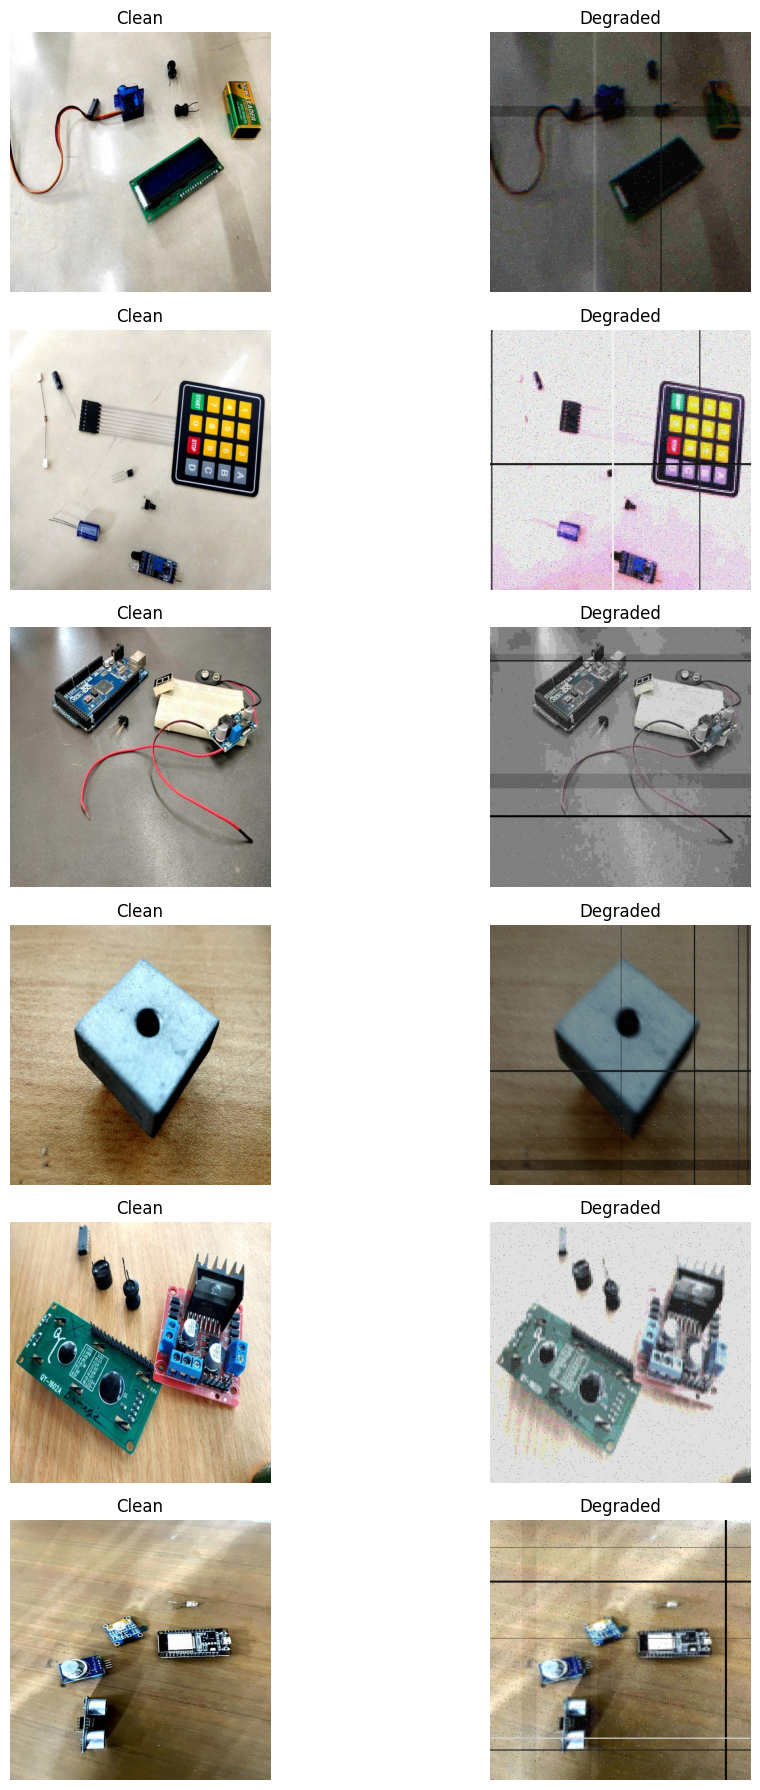

In [10]:
# === Visual check: clean vs degraded ===

import matplotlib.pyplot as plt
import random
import cv2

sample_imgs = random.sample(train_imgs, 6)

plt.figure(figsize=(12, 18))

for i, img_path in enumerate(sample_imgs):
    clean = cv2.imread(str(img_path))
    clean = cv2.cvtColor(clean, cv2.COLOR_BGR2RGB)

    degraded_path = DOMAIN_ROOT / "images/train" / img_path.name
    degraded = cv2.imread(str(degraded_path))
    degraded = cv2.cvtColor(degraded, cv2.COLOR_BGR2RGB)

    plt.subplot(6, 2, 2 * i + 1)
    plt.imshow(clean)
    plt.title("Clean")
    plt.axis("off")

    plt.subplot(6, 2, 2 * i + 2)
    plt.imshow(degraded)
    plt.title("Degraded")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
# === Fine-tuning on degraded dataset ===

from ultralytics import YOLO
from pathlib import Path
import torch
import gc
import os
import random
import numpy as np


gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Если best_weights_path уже есть из предыдущей ячейки — используем его.
# Если нет, автоматически ищем последний best.pt.
try:
    best_weights_path
    print("Using existing best_weights_path:", best_weights_path)
except NameError:
    possible_best_weights = sorted(
        Path("/runs/detect").rglob("weights/best.pt"),
        key=lambda p: p.stat().st_mtime,
        reverse=True
    )
    assert len(possible_best_weights) > 0, "Не найден best.pt"
    best_weights_path = possible_best_weights[0]
    print("Found best_weights_path:", best_weights_path)

domain_model = YOLO(str(best_weights_path))

domain_results = domain_model.train(
    data=str(domain_yaml_path),

    epochs=35,
    imgsz=640,
    batch=8,
    seed=SEED,
    device=0 if torch.cuda.is_available() else "cpu",
    workers=2,

    project="/runs",
    name="domain_finetune_heavy_degradation_seed993",
    exist_ok=True,

    patience=12,

    optimizer="AdamW",
    lr0=0.00025,                     # маленький lr: это fine-tuning, не обучение с нуля
    lrf=0.01,
    weight_decay=0.0005,
    warmup_epochs=2,
    cos_lr=True,

    # Геометрию делаем мягче: проблема не в bbox-геометрии, а в плохом качестве пикселей.
    hsv_h=0.010,
    hsv_s=0.25,
    hsv_v=0.25,

    degrees=4.0,
    translate=0.04,
    scale=0.15,
    shear=1.0,
    perspective=0.0001,

    fliplr=0.5,
    flipud=0.05,

    # Mosaic почти убираем: test не является mosaic-коллажем.
    mosaic=0.10,
    mixup=0.0,
    copy_paste=0.0,
    close_mosaic=5,

    verbose=True,
)

domain_run_dir = Path(domain_model.trainer.save_dir)
domain_best_weights_path = domain_run_dir / "weights" / "best.pt"

assert domain_best_weights_path.exists(), f"Не найден domain best.pt: {domain_best_weights_path}"

print("Domain fine-tuning completed.")
print("domain_best_weights_path:", domain_best_weights_path)

Using existing best_weights_path: /content/runs/detect/train/weights/best.pt
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=5, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/competition_data/yolo_degraded_dataset/data.yaml, degrees=4.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.05, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.25, hsv_v=0.25, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.00025, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/detect/train/weights/best.pt, momentum=0.937, mo

In [12]:
# === Validate fine-tuned model on degraded validation ===

domain_best_model = YOLO(str(domain_best_weights_path))

domain_val_metrics = domain_best_model.val(
    data=str(domain_yaml_path),
    imgsz=640,
    batch=8,
    device=0 if torch.cuda.is_available() else "cpu",
    verbose=True
)

print(domain_val_metrics.results_dict)

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,869,868 parameters, 0 gradients, 78.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2308.5±572.0 MB/s, size: 269.9 KB)
val: Scanning /content/competition_data/yolo_degraded_dataset/labels/val.cache... 340 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 340/340 158.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 43/43 3.9it/s 11.0s
                   all        340       2103      0.576      0.469      0.498      0.306
               class_0         25         26      0.418        0.5      0.493      0.293
               class_1         21         21      0.529      0.619      0.641      0.393
               class_2         36         36      0.628      0.188      0.275      0.165
               class_3         29         30      0.481        0.9      0.782      0.647
               

In [13]:
# === Inference with domain fine-tuned model ===

from pathlib import Path
import pandas as pd
import torch
from tqdm.notebook import tqdm
from ultralytics import YOLO

best_model = YOLO(str(domain_best_weights_path))

CONF = 0.01
IOU = 0.60
IMG_SIZE = 640
MAX_DET = 300
FALLBACK_PRED = "50 0.001000 268 262 372 378"

sample_df = pd.read_csv(sample_submission_path)
sample_ids = sample_df["image_id"].astype(str).tolist()

test_images = sorted(list(Path(test_images_dir).glob("*.jpg")))

submission_rows = []

for img_path in tqdm(test_images, desc="Predicting test with domain fine-tuned model"):
    results = best_model.predict(
        source=str(img_path),
        imgsz=IMG_SIZE,
        conf=CONF,
        iou=IOU,
        max_det=MAX_DET,
        augment=True,
        verbose=False,
        device=0 if torch.cuda.is_available() else "cpu"
    )

    r = results[0]
    pred_tokens = []

    if r.boxes is not None and len(r.boxes) > 0:
        boxes = r.boxes.xyxy.cpu().numpy()
        scores = r.boxes.conf.cpu().numpy()
        classes = r.boxes.cls.cpu().numpy().astype(int)

        for cls_id, score, box in zip(classes, scores, boxes):
            x1, y1, x2, y2 = box

            x1 = max(0, min(639, x1))
            y1 = max(0, min(639, y1))
            x2 = max(0, min(639, x2))
            y2 = max(0, min(639, y2))

            if x2 <= x1 or y2 <= y1:
                continue

            pred_tokens.extend([
                str(int(cls_id)),
                f"{float(score):.6f}",
                f"{x1:.0f}",
                f"{y1:.0f}",
                f"{x2:.0f}",
                f"{y2:.0f}",
            ])

    submission_rows.append({
        "image_id": img_path.stem,
        "PredictionString": " ".join(pred_tokens)
    })

submission_df = pd.DataFrame(submission_rows)

# strict alignment with sample_submission
submission_df["image_id"] = submission_df["image_id"].astype(str)
submission_df["PredictionString"] = submission_df["PredictionString"].fillna("").astype(str)

submission_df = submission_df.set_index("image_id").reindex(sample_ids).reset_index()
submission_df["PredictionString"] = submission_df["PredictionString"].fillna("").astype(str)

# fill empty predictions to avoid Kaggle null error
empty_mask = submission_df["PredictionString"].str.strip().eq("")
print("Empty predictions before fallback:", int(empty_mask.sum()))

submission_df.loc[empty_mask, "PredictionString"] = FALLBACK_PRED

# final checks
submission_df["PredictionString"] = submission_df["PredictionString"].fillna("").astype(str)

assert submission_df.shape[0] == sample_df.shape[0]
assert submission_df.isna().sum().sum() == 0

token_counts = submission_df["PredictionString"].apply(lambda s: len(str(s).strip().split()))
assert (token_counts % 6 == 0).all(), "Есть строки с некратным 6 числом токенов"

box_counts = token_counts // 6
print("Box count stats:")
print(box_counts.describe())

out_path = Path("/sample_submission_domain_finetuned.csv")
submission_df.to_csv(out_path, index=False)

print("Saved:", out_path)
display(submission_df.head())# === Simple robust inference without custom TTA/WBF ===

from pathlib import Path
import pandas as pd
import torch
from tqdm.notebook import tqdm

CONF = 0.01
IOU = 0.60
IMG_SIZE = 640
MAX_DET = 300

test_images = sorted(list(test_images_dir.glob("*.jpg")))

submission_rows = []

for img_path in tqdm(test_images, desc="Predicting test"):
    results = best_model.predict(
        source=str(img_path),          # важно: путь, не cv2 RGB array
        imgsz=IMG_SIZE,
        conf=CONF,
        iou=IOU,
        max_det=MAX_DET,
        augment=True,                 # встроенный YOLO TTA, безопаснее ручного
        verbose=False,
        device=0 if torch.cuda.is_available() else "cpu"
    )

    r = results[0]
    pred_tokens = []

    if r.boxes is not None and len(r.boxes) > 0:
        boxes = r.boxes.xyxy.cpu().numpy()
        scores = r.boxes.conf.cpu().numpy()
        classes = r.boxes.cls.cpu().numpy().astype(int)

        for cls_id, score, box in zip(classes, scores, boxes):
            x1, y1, x2, y2 = box

            x1 = max(0, min(639, x1))
            y1 = max(0, min(639, y1))
            x2 = max(0, min(639, x2))
            y2 = max(0, min(639, y2))

            if x2 <= x1 or y2 <= y1:
                continue

            pred_tokens.extend([
                str(int(cls_id)),
                f"{float(score):.6f}",
                f"{x1:.0f}",
                f"{y1:.0f}",
                f"{x2:.0f}",
                f"{y2:.0f}",
            ])

    submission_rows.append({
        "image_id": img_path.stem,
        "PredictionString": " ".join(pred_tokens)
    })

submission_df = pd.DataFrame(submission_rows)

print("submission_df shape:", submission_df.shape)
print("empty predictions:", (submission_df["PredictionString"].str.strip() == "").sum())
display(submission_df.head())

Predicting test with domain fine-tuned model:   0%|          | 0/424 [00:00<?, ?it/s]

Empty predictions before fallback: 0
Box count stats:
count    424.000000
mean      50.601415
std       23.731339
min        4.000000
25%       34.000000
50%       48.000000
75%       63.250000
max      143.000000
Name: PredictionString, dtype: float64
Saved: /sample_submission_domain_finetuned.csv


,image_id,PredictionString
0,IMG20240228122809_jpg.rf.bb184f37aa98d96f1db1a...,30 0.936982 165 352 404 540 38 0.691653 54 415...
1,IMG20240228122949_jpg.rf.f763b523e7bb4e7250796...,30 0.823929 42 113 364 358 39 0.320998 142 373...
2,IMG20240228122955_jpg.rf.18d6c6ad9c8c69153da34...,30 0.918235 129 224 419 592 45 0.349813 142 56...
3,IMG20240228123115_jpg.rf.3b9ae83d0bc7242bafe52...,30 0.944010 41 77 282 388 38 0.863563 573 139 ...
4,IMG20240228123131_jpg.rf.84cf43cf1c7a8d09dc507...,30 0.461354 0 161 259 439 45 0.456087 210 421 ...


Predicting test:   0%|          | 0/424 [00:00<?, ?it/s]

submission_df shape: (424, 2)
empty predictions: 0


,image_id,PredictionString
0,IMG20240228122809_jpg.rf.bb184f37aa98d96f1db1a...,30 0.936982 165 352 404 540 38 0.691653 54 415...
1,IMG20240228122949_jpg.rf.f763b523e7bb4e7250796...,30 0.823929 42 113 364 358 39 0.320998 142 373...
2,IMG20240228122955_jpg.rf.18d6c6ad9c8c69153da34...,30 0.918235 129 224 419 592 45 0.349813 142 56...
3,IMG20240228123115_jpg.rf.3b9ae83d0bc7242bafe52...,30 0.944010 41 77 282 388 38 0.863563 573 139 ...
4,IMG20240228123131_jpg.rf.84cf43cf1c7a8d09dc507...,30 0.461354 0 161 259 439 45 0.456087 210 421 ...


In [ ]:
# я не очень понимаю как скор получается большим, если моделька выдает так много боксов на фото
# медиана на трейне всего 6
# ноооо не нужно чинить то что работает i guess????

In [16]:
# === Final submission alignment and no-null postprocessing ===

from collections import Counter
import numpy as np
from pathlib import Path

sample_df = pd.read_csv(sample_submission_path)
sample_ids = sample_df["image_id"].astype(str).tolist()

submission_df["image_id"] = submission_df["image_id"].astype(str)
submission_df["PredictionString"] = submission_df["PredictionString"].fillna("").astype(str)

# reindex строго в порядке sample_submission
submission_df = submission_df.set_index("image_id").reindex(sample_ids).reset_index()

# после reindex снова могут появиться NaN, если где-то не совпал image_id
submission_df["PredictionString"] = submission_df["PredictionString"].fillna("").astype(str)

# fallback
FALLBACK_PRED = "50 0.001000 268 262 372 378"

empty_mask = submission_df["PredictionString"].str.strip().eq("")
print("Empty after reindex before fallback:", int(empty_mask.sum()))

submission_df.loc[empty_mask, "PredictionString"] = FALLBACK_PRED

# финальная проверка
submission_df["PredictionString"] = submission_df["PredictionString"].fillna("").astype(str)
empty_after = submission_df["PredictionString"].str.strip().eq("").sum()
print("Empty after fallback:", int(empty_after))

assert empty_after == 0
assert submission_df.isna().sum().sum() == 0
assert submission_df.shape[0] == sample_df.shape[0]

def valid_token_count(s):
    return len(str(s).strip().split()) % 6 == 0

bad_mask = ~submission_df["PredictionString"].apply(valid_token_count)
print("Bad token rows:", int(bad_mask.sum()))
assert bad_mask.sum() == 0

out_path = Path.cwd() / "sample_submission.csv"
submission_df.to_csv(out_path, index=False)

print("Saved:", out_path)
print("Exists:", out_path.exists())
print("Shape:", submission_df.shape)
print("Nulls:")
print(submission_df.isna().sum())
display(submission_df.head())

Empty after reindex before fallback: 0
Empty after fallback: 0
Bad token rows: 0
Saved: /content/sample_submission.csv
Exists: True
Shape: (424, 2)
Nulls:
image_id            0
PredictionString    0
dtype: int64


,image_id,PredictionString
0,IMG20240228122809_jpg.rf.bb184f37aa98d96f1db1a...,30 0.936982 165 352 404 540 38 0.691653 54 415...
1,IMG20240228122949_jpg.rf.f763b523e7bb4e7250796...,30 0.823929 42 113 364 358 39 0.320998 142 373...
2,IMG20240228122955_jpg.rf.18d6c6ad9c8c69153da34...,30 0.918235 129 224 419 592 45 0.349813 142 56...
3,IMG20240228123115_jpg.rf.3b9ae83d0bc7242bafe52...,30 0.944010 41 77 282 388 38 0.863563 573 139 ...
4,IMG20240228123131_jpg.rf.84cf43cf1c7a8d09dc507...,30 0.461354 0 161 259 439 45 0.456087 210 421 ...


In [17]:
# === Save the submission file ===

# Ensure order matches sample submission
sample_ids = list(pd.read_csv(sample_submission_path)['image_id'])

submission_df = submission_df.set_index('image_id').reindex(sample_ids).reset_index()
submission_df['PredictionString'] = submission_df['PredictionString'].fillna('')

out_path = extract_root / 'sample_submission.csv'
submission_df.to_csv(out_path, index=False)
print('Submission file saved to', out_path)


Submission file saved to /content/competition_data/sample_submission.csv


In [18]:
# from google.colab import files
# files.download("/content/competition_data/sample_submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>